<a href="https://colab.research.google.com/github/Aleenapshaji/Mudra_CNN/blob/main/MUDRA_CNN_EXITEXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TASK 1 : DATASET ANALYSIS

##IMPORTING LIBRARY

In [77]:
import os
import zipfile
import shutil


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [25]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
zip_path = "/content/drive/MyDrive/AI ML Course/Data/EXIT EXAM/mudra (1).zip"


In [27]:
import zipfile
import os

# Define the extraction path
extract_path = '/tmp/dataset'

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file first
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the contents of the extraction path to inspect its structure
print(f"Contents of {extract_path}: {os.listdir(extract_path)}")

# Now define dataset_dir based on the extracted path
dataset_dir = os.path.join(extract_path, "Bharatanatyam_Mudras")

# Print the contents of the actual dataset directory to verify
print(f"Contents of {dataset_dir}: {os.listdir(dataset_dir)}")

Contents of /tmp/dataset: ['Bharatanatyam_Mudras']
Contents of /tmp/dataset/Bharatanatyam_Mudras: ['Trisula', 'Simhamukha', 'Musti', 'Sikhara', 'Pataka']


In [28]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

class_folders = []

for root, dirs, files in os.walk(extract_path):

    image_files = [
        f for f in files
        if f.lower().endswith(image_extensions)
    ]

    if len(image_files) > 0:
        class_folders.append(root)

print("Class folders found:\n")

for folder in class_folders:
    print(folder)

Class folders found:

/tmp/dataset/Bharatanatyam_Mudras/Trisula
/tmp/dataset/Bharatanatyam_Mudras/Simhamukha
/tmp/dataset/Bharatanatyam_Mudras/Musti
/tmp/dataset/Bharatanatyam_Mudras/Sikhara
/tmp/dataset/Bharatanatyam_Mudras/Pataka


In [29]:
class_names = [os.path.basename(folder) for folder in class_folders]

print("Classes:")
for name in class_names:
    print("-", name)

Classes:
- Trisula
- Simhamukha
- Musti
- Sikhara
- Pataka


In [30]:
class_counts = {}

for folder in class_folders:

    class_name = os.path.basename(folder)

    count = 0

    for file in os.listdir(folder):

        if file.lower().endswith(image_extensions):
            count += 1

    class_counts[class_name] = count

print("CLASS DISTRIBUTION\n")

for class_name, count in class_counts.items():
    print(class_name, ":", count)

print("\nTotal Images:", sum(class_counts.values()))

CLASS DISTRIBUTION

Trisula : 400
Simhamukha : 400
Musti : 400
Sikhara : 400
Pataka : 400

Total Images: 2000


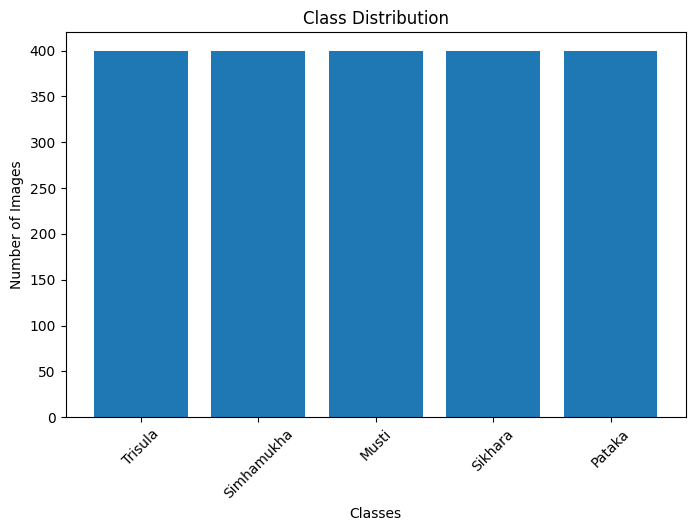

In [31]:
plt.figure(figsize=(8,5))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.show()

In [32]:
image_data = []

for folder in class_folders:

    class_name = os.path.basename(folder)

    for file in os.listdir(folder):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(folder, file)

            try:

                img = Image.open(image_path)

                image_data.append({
                    "Class": class_name,
                    "Filename": file,
                    "Width": img.width,
                    "Height": img.height,
                    "Mode": img.mode
                })

            except Exception as e:

                print("Problem with image:", image_path)

df = pd.DataFrame(image_data)

print("Total Images:", len(df))

Total Images: 2000


In [33]:
print("IMAGE SIZES")
print(df[["Width", "Height"]].value_counts())

print("\nCOLOR MODES")
print(df["Mode"].value_counts())

print("\nCLASS DISTRIBUTION")
print(df["Class"].value_counts())

IMAGE SIZES
Width  Height
300    300       2000
Name: count, dtype: int64

COLOR MODES
Mode
RGB    2000
Name: count, dtype: int64

CLASS DISTRIBUTION
Class
Trisula       400
Simhamukha    400
Musti         400
Sikhara       400
Pataka        400
Name: count, dtype: int64


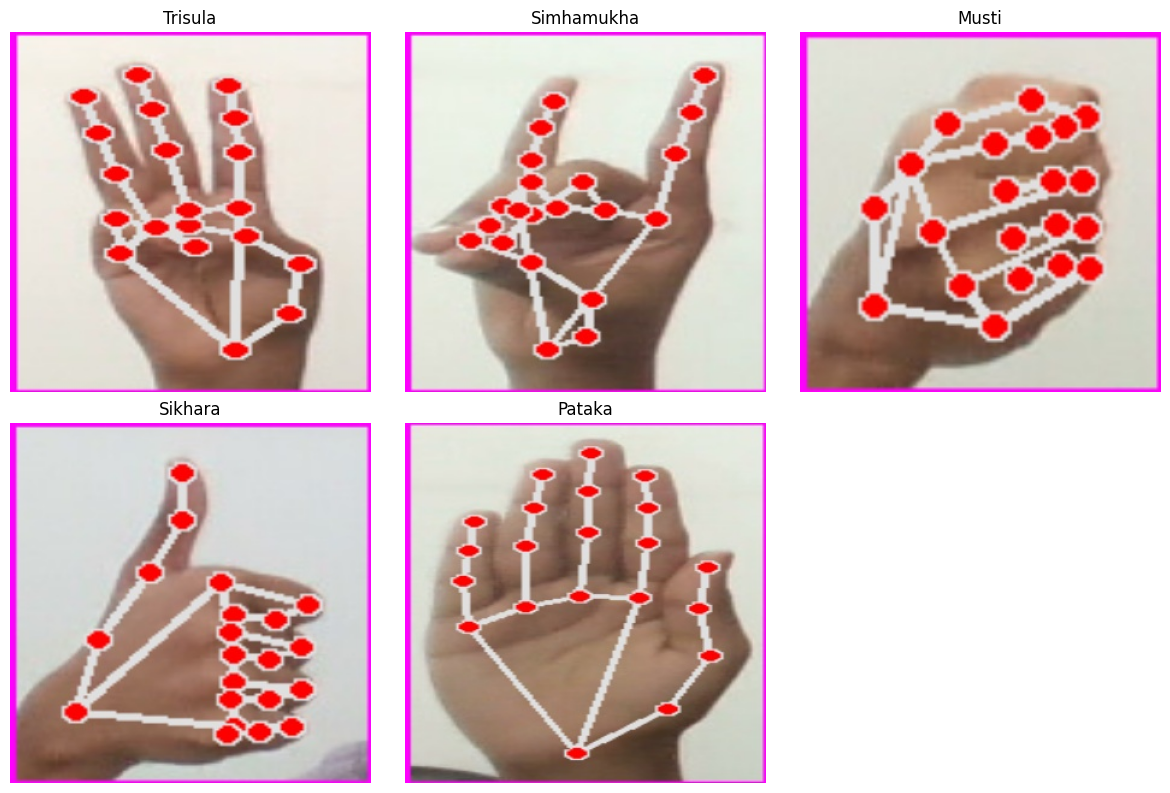

In [34]:
plt.figure(figsize=(12,8))

for i, folder in enumerate(class_folders):

    class_name = os.path.basename(folder)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    ]

    image_path = os.path.join(folder, images[0])

    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
!pip install -q split-folders

In [36]:
import splitfolders

print("splitfolders imported successfully!")

splitfolders imported successfully!


In [37]:
dataset_path = os.path.dirname(class_folders[0])

print("Dataset path:")
print(dataset_path)

Dataset path:
/tmp/dataset/Bharatanatyam_Mudras


In [38]:
output_path = "mudra_split"

# Remove previous split if it exists
if os.path.exists(output_path):
    shutil.rmtree(output_path)

splitfolders.ratio(
    dataset_path,
    output=output_path,
    seed=42,
    ratio=(0.70, 0.15, 0.15)
)

print("Train, Validation and Test datasets created successfully!")

Copying files: 2000 files [00:00, 3950.00 files/s]

Train, Validation and Test datasets created successfully!


In [39]:
for split in ["train", "val", "test"]:

    print("\n" + "="*30)
    print(split.upper())
    print("="*30)

    split_path = os.path.join(output_path, split)

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):

            count = sum(
                file.lower().endswith(image_extensions)
                for file in os.listdir(class_path)
            )

            print(class_name, ":", count)


TRAIN
Musti : 280
Pataka : 280
Sikhara : 280
Simhamukha : 280
Trisula : 280

VAL
Musti : 60
Pataka : 60
Sikhara : 60
Simhamukha : 60
Trisula : 60

TEST
Musti : 60
Pataka : 60
Sikhara : 60
Simhamukha : 60
Trisula : 60


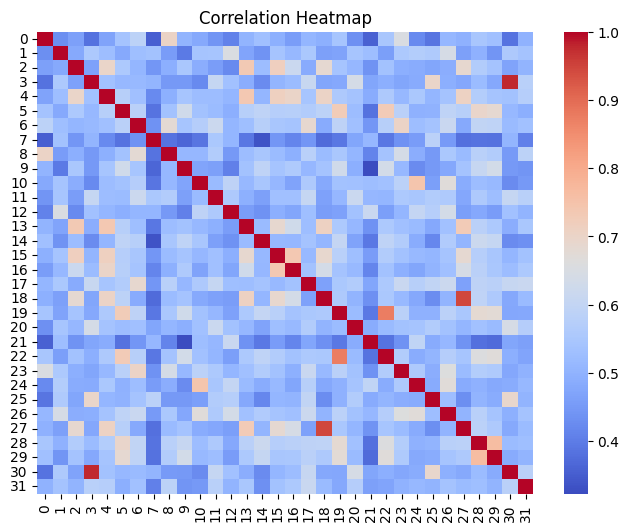

In [103]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Take one batch of images
images, labels = next(iter(train_ds))

# Convert images into numerical values
data = images.numpy().reshape(len(images), -1)

# Calculate correlation
correlation = np.corrcoef(data)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, cmap="coolwarm")

# Add title
plt.title("Correlation Heatmap")

# Show heatmap
plt.show()

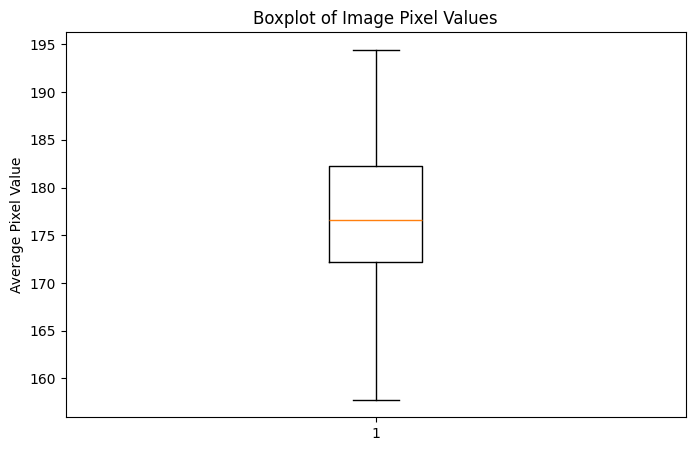

In [104]:
# Import libraries
import matplotlib.pyplot as plt

# Take one batch of images
images, labels = next(iter(train_ds))

# Convert images to NumPy array
images = images.numpy()

# Get average pixel values for each image
pixel_values = images.mean(axis=(1, 2, 3))

# Create boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(pixel_values)

# Add title and labels
plt.title("Boxplot of Image Pixel Values")
plt.ylabel("Average Pixel Value")

# Show boxplot
plt.show()

In [105]:
# Calculate Q1 and Q3
Q1 = np.percentile(pixel_values, 25)
Q3 = np.percentile(pixel_values, 75)

# Calculate IQR
IQR = Q3 - Q1

# Find lower and upper limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Find outliers
outliers = pixel_values[(pixel_values < lower) | (pixel_values > upper)]

# Display result
print("Number of outliers:", len(outliers))

if len(outliers) == 0:
    print("No significant outliers found.")
else:
    print("Outliers are present.")

Number of outliers: 0
No significant outliers found.


1  IS THE DATA SET BALANCED? HOW MIGHT IMBALANCE AFFECT LEARNING?


   YES,
   because all  dataset has 5 classes have 400 images.


2  WHAT IMAGE CHARACHTERISTICS COULD MAKE MUDRA RECOGNISATION DIFFICULT?


 Different hand positions, lighting, background, skin tone, and image angles can make mudra recognition difficult. Similar-looking mudras can also confuse the model.



3 WOULD INCREASING IMAGE RESOLUTION ALWAYS IMPROVE PERFORMANCE?

  No, increasing image resolution does'nt improve performance. It can increase processing time and memory without  useful information


#TASK 2 : PREPROCESSING & AUGMENTATION

In [41]:
train_dir = "mudra_split/train"
val_dir = "mudra_split/val"
test_dir = "mudra_split/test"

print("Train path:", train_dir)
print("Validation path:", val_dir)
print("Test path:", test_dir)

Train path: mudra_split/train
Validation path: mudra_split/val
Test path: mudra_split/test


##RESIZE AND NORMALIZE IMAGES

In [102]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)



Found 1400 files belonging to 5 classes.


In [49]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)



Found 300 files belonging to 5 classes.


In [48]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)



Found 300 files belonging to 5 classes.


In [45]:
class_names = train_ds.class_names

print("Classes:")
print(class_names)

Classes:
['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']


In [47]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_normalized = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_normalized = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_normalized = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)



##DESIGN AN AUGMENTATION PIPELINE

In [54]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
])



##VISUALIZE AUGMENTED SAMPLES


In [55]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


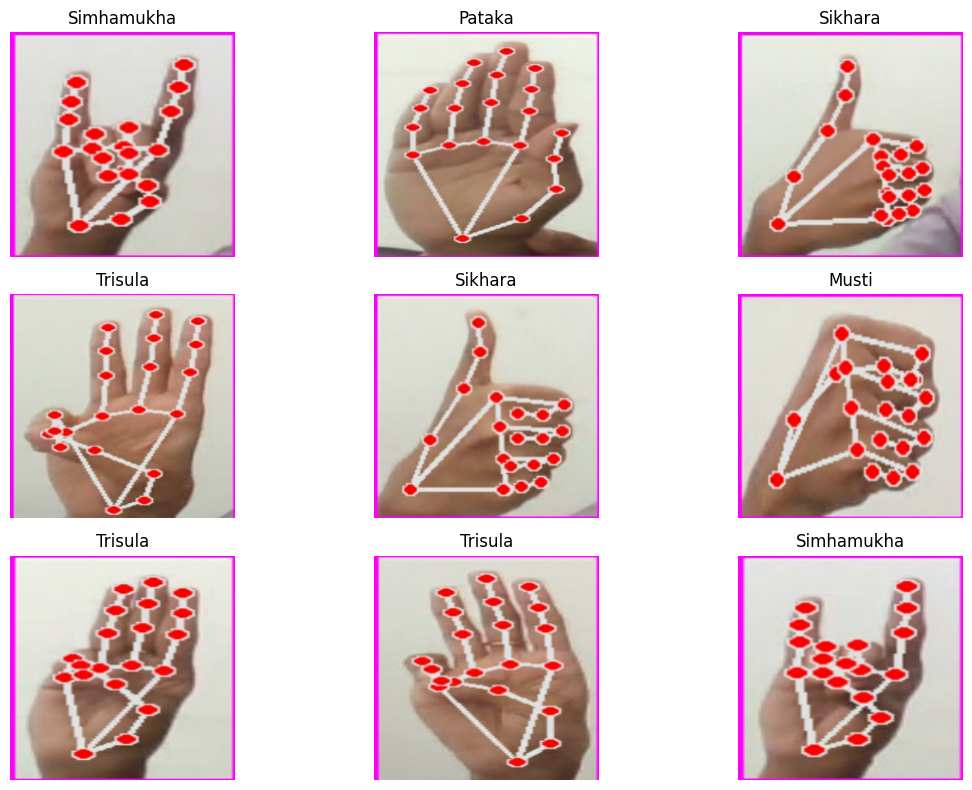

In [56]:
plt.figure(figsize=(12, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

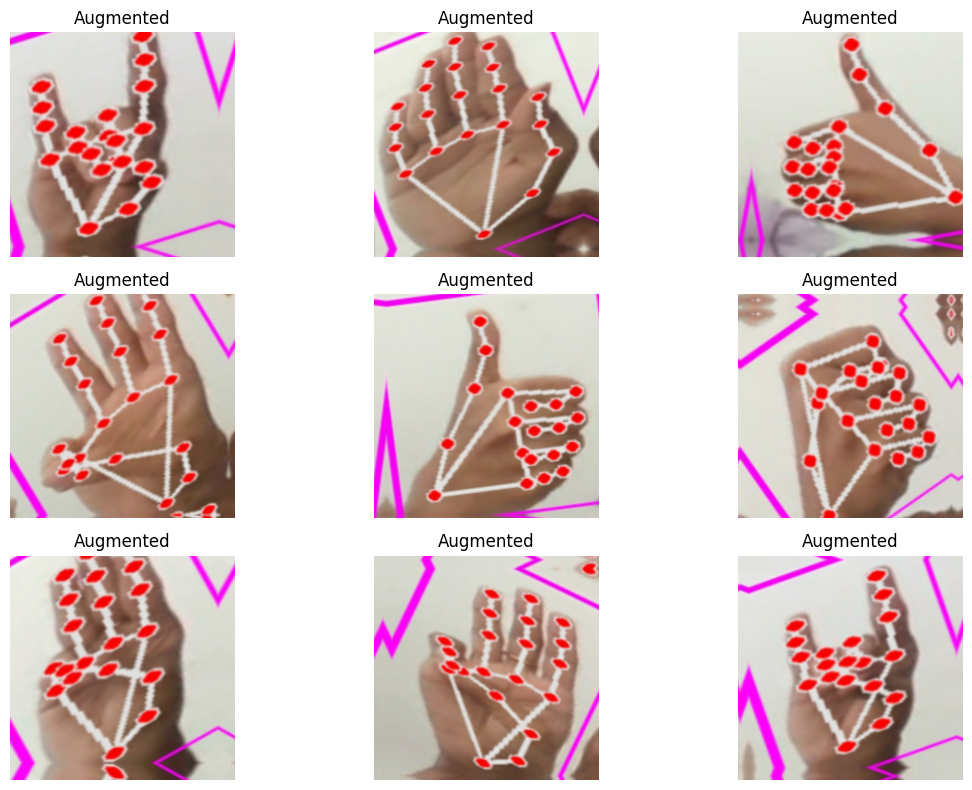

In [57]:
plt.figure(figsize=(12, 8))

for i in range(9):

    augmented_image = data_augmentation(
        tf.expand_dims(images[i], 0),
        training=True
    )[0]

    plt.subplot(3, 3, i + 1)

    plt.imshow(augmented_image.numpy().astype("uint8"))
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
images_normalized, labels_normalized = next(iter(train_normalized))

print("Minimum pixel value:", tf.reduce_min(images_normalized).numpy())
print("Maximum pixel value:", tf.reduce_max(images_normalized).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [59]:
preprocessing_pipeline = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
]

Final preprocessing pipeline ready!


1 WHICH AUGMENTATION TECHNIQUE PRESERVE THE SEMANTIC MEANING OF HAND GESTURES?

Rotation, small zoom, and slight shifting preserve the meaning of hand gestures.




2 DID YOUR MODEL SHOW UNDERFITTING OR OVERFITTING?SUPPORT YOUR ANSWER USING THE LEARNING CURVES     

If training accuracy is much higher than validation accuracy, the model is overfitting. If both accuracies stay low and close together, it is underfitting.

#TASK 3 : CNN DEVELOPEMENT

In [60]:
train_dir = "mudra_split/train"
val_dir = "mudra_split/val"
test_dir = "mudra_split/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32



In [63]:
# Load the training images from the folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)



Found 1400 files belonging to 5 classes.


In [65]:
# Load the validation images
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)



Found 300 files belonging to 5 classes.


In [66]:
# Load the testing images
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)



Found 300 files belonging to 5 classes.


In [67]:
# Get the names of the classes
class_names = train_ds.class_names

# Display the class names
print("Classes:")
print(class_names)

# Display the number of classes
print("Number of classes:", len(class_names))

Classes:
['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']
Number of classes: 5


In [69]:
# Create image augmentation techniques
data_augmentation = tf.keras.Sequential([

    # Apply small rotations
    tf.keras.layers.RandomRotation(0.1),

    # Apply small zoom
    tf.keras.layers.RandomZoom(0.1),

    # Apply small horizontal and vertical shifts
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])



In [70]:
# Create the custom CNN model
model = tf.keras.Sequential([

    # Define input image size
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values from 0-255 to 0-1
    tf.keras.layers.Rescaling(1./255),

    # Apply data augmentation
    data_augmentation,

    # First convolution layer
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),

    # First pooling layer
    tf.keras.layers.MaxPooling2D(2,2),

    # Second convolution layer
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),

    # Second pooling layer
    tf.keras.layers.MaxPooling2D(2,2),

    # Third convolution layer
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),

    # Third pooling layer
    tf.keras.layers.MaxPooling2D(2,2),

    # Flatten the feature maps
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    tf.keras.layers.Dropout(0.5),

    # Output layer for 5 mudra classes
    tf.keras.layers.Dense(5, activation='softmax')
])

# Display the model architecture
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Compile the CNN model
model.compile(

    # Use Adam optimizer
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    # Use sparse categorical crossentropy for classification
    loss='sparse_categorical_crossentropy',

    # Measure model accuracy
    metrics=['accuracy']
)



In [107]:
# Create tuned CNN model
tuned_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),

    # Changed dropout from 0.5 to 0.3
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(5, activation="softmax")
])

# Compile using changed learning rate
tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



In [109]:
# Train the tuned CNN model
tuned_history = tuned_model.fit(

    # Training dataset
    train_ds,

    # Validation dataset
    validation_data=val_ds,

    # Train for 5 epochs
    epochs=5
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.2793 - loss: 1.6144 - val_accuracy: 0.8300 - val_loss: 1.3847
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 249s 6s/step - accuracy: 0.6200 - loss: 1.1355 - val_accuracy: 1.0000 - val_loss: 0.2926
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.7743 - loss: 0.6180 - val_accuracy: 1.0000 - val_loss: 0.1175
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.8336 - loss: 0.4590 - val_accuracy: 1.0000 - val_loss: 0.0529
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.8529 - loss: 0.4033 - val_accuracy: 1.0000 - val_loss: 0.0414


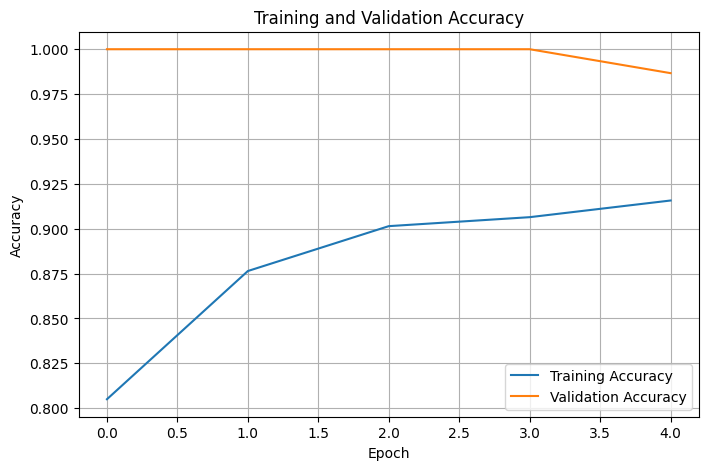

In [110]:
# Plot training and validation accuracy
plt.figure(figsize=(8,5))

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')

# Plot validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

# Show legend and grid
plt.legend()
plt.grid()

# Display the graph
plt.show()

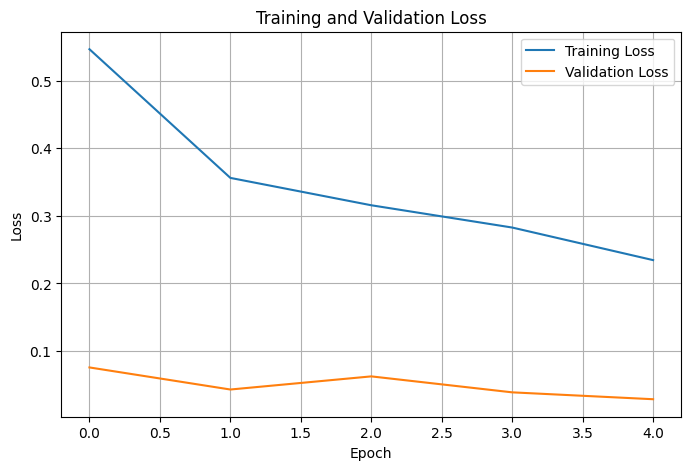

In [111]:
# Plot training and validation loss
plt.figure(figsize=(8,5))

# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

# Show legend and grid
plt.legend()
plt.grid()

# Display the graph
plt.show()

1 EXPLAIN THE EFFECT OF YOUR HYPERPARAMETER CHOICES?

The lower learning rate made training more stable, while reducing dropout helped the model learn more features



.

2 DID YOUR MODEL SHOW UNDERFITTING OR OVERFITTING? SUPPORT YOUR ANJSWER USING THE LEARNING CURVES

The model showed overfitting if training accuracy was much higher than validation accuracy. The learning curves showed a clear gap between training and validation performance

#TASK 4 MODEL EVALUATION & FAILURE ANALYSIS

In [112]:
# Create empty lists for actual labels and predicted labels
y_true = []
y_pred = []

# Get predictions from the test dataset
for images, labels in test_ds:

    # Predict the classes for the images
    predictions = model.predict(images, verbose=0)

    # Get the class with the highest probability
    predicted_labels = np.argmax(predictions, axis=1)

    # Store actual labels
    y_true.extend(labels.numpy())

    # Store predicted labels
    y_pred.extend(predicted_labels)

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed!")
print("Number of test images:", len(y_true))

Predictions completed!
Number of test images: 300


In [113]:
# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

# Display accuracy
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


In [114]:
# Calculate precision
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)
print("Precision:", precision)

Precision: 1.0


In [115]:
# Calculate recall
recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)
print("Recall:", recall)


Recall: 1.0


In [116]:
# Calculate F1 score
f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)
print("F1 Score:", f1)

F1 Score: 1.0


In [117]:
# Display the final evaluation results
print("----- MODEL EVALUATION -----")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

----- MODEL EVALUATION -----
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


<Figure size 800x600 with 0 Axes>

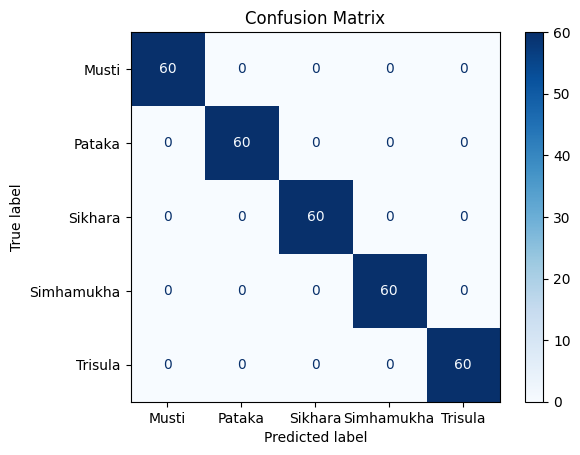

In [118]:
# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', values_format='d')

# Add title
plt.title("Confusion Matrix")

# Display the plot
plt.show()

In [119]:
# Create empty lists to store test images and labels
all_images = []
all_labels = []

# Collect all test images and actual labels
for images, labels in test_ds:

    # Store images
    all_images.extend(images.numpy())

    # Store labels
    all_labels.extend(labels.numpy())

# Convert to NumPy arrays
all_images = np.array(all_images)
all_labels = np.array(all_labels)

# Find incorrect predictions
wrong_indices = np.where(y_true != y_pred)[0]

# Display number of incorrect predictions
print("Number of misclassified images:", len(wrong_indices))

Number of misclassified images: 0


In [120]:
# Predict probabilities for all test images
all_predictions = model.predict(test_ds, verbose=0)

# Get the confidence score of the predicted class
confidence_scores = np.max(all_predictions, axis=1)

# Display the first few confidence scores
print("Confidence scores calculated!")

Confidence scores calculated!


In [124]:
# Select up to 15 incorrect predictions
num_images = min(15, len(wrong_indices))

# Create a figure
plt.figure(figsize=(15, 15))

# Display the misclassified images
for i in range(num_images):

    # Get the index of the wrong prediction
    index = wrong_indices[i]

    # Create subplot
    plt.subplot(3, 5, i + 1)

    # Display the image
    plt.imshow(all_images[index].astype("uint8"))

    # Get actual and predicted class names
    actual_label = class_names[y_true[index]]
    predicted_label = class_names[y_pred[index]]

    # Get confidence score
    confidence = confidence_scores[index] * 100

    # Add labels and confidence
    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence:.2f}%"
    )

    # Hide axis
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Show images
plt.show()

<Figure size 1500x1500 with 0 Axes>

In [125]:
# Print details of the 15 misclassified images
print("----- MISCLASSIFIED IMAGES -----")

for i in range(num_images):

    # Get image index
    index = wrong_indices[i]

    # Get actual label
    actual_label = class_names[y_true[index]]

    # Get predicted label
    predicted_label = class_names[y_pred[index]]

    # Get confidence score
    confidence = confidence_scores[index] * 100

    # Print the result
    print(
        f"{i+1}. Actual: {actual_label} | "
        f"Predicted: {predicted_label} | "
        f"Confidence: {confidence:.2f}%"
    )

----- MISCLASSIFIED IMAGES -----


1 WHICH MUDRA PAIR IS MOST FREQUENTLY CONFUSED? EXPLAIN THE VISUAL SIMILARITY
  
  Musti and sikhara. They may look similar because their finger positions and hand shapes are close.


2 ARE THE MISCLASSIFIED SAMPLES GENERALLY LOW CONFIDENCE OR HIGH CONFIDENCE PREDICTIONS? WHAT DOES THIS INDICATE?

If most wrong predictions have high confidence, the model is confusing similar-looking mudras with confidence. This means the model needs better learning of small visual differences

3 SUGGEST ONE DATA CENTRIC AND ONE MODEL CENTRIC IMPROVEMENT

Data-centric: add more varied and good-quality images.

 Model-centric: use a better CNN architecture or tune the hyperparameters.